# 05 — EDA Basic

Sample description, missing data audit, continuous and categorical variable distributions, outlier detection, and Spearman correlation network.

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

DATA_PATH = '../data/processed/combined_data.csv'
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())


Shape: (25, 19)
Columns: ['name', 'age_group', 'gender', 'bmi', 'training_category', 'early_life_training', 'end_range_control', 'weekly_volume', 'injury_presence', 'chronic_pain', 'sleep_duration', 'sleep_quality', 'physical_recovery', 'mental_recovery', 'stress_score', 'sitting_time', 'sedentary_score', 'hypermobility', 'mwi']


## 1. Sample size flow

In [141]:
print('=== Sample Size Flow ===')
print(f'Total participants: {len(df)}')
print()

print('--- Gender breakdown ---')
print(df['gender'].value_counts().to_string())
print()

print('--- Age group breakdown ---')
print(df['age_group'].value_counts().sort_index().to_string())
print()

print('--- Hypermobility data ---')
hyper_available = df['hypermobility'].notna().sum()
hyper_missing = df['hypermobility'].isna().sum()
print(f'Have hypermobility data: {hyper_available}')
print(f'Missing hypermobility data: {hyper_missing}')
print()

if 'mwi' in df.columns:
    mwi_available = df['mwi'].notna().sum()
    mwi_missing = df['mwi'].isna().sum()
    print('--- MWI data ---')
    print(f'Have MWI score: {mwi_available}')
    print(f'Missing MWI score: {mwi_missing}')
else:
    print('--- MWI data ---')
    print('mwi column not yet merged (run notebook 03 first)')


=== Sample Size Flow ===
Total participants: 25

--- Gender breakdown ---
gender
Female    17
Male       8

--- Age group breakdown ---
age_group
18-29    16
30-39     6
40-49     1
50-59     2

--- Hypermobility data ---
Have hypermobility data: 25
Missing hypermobility data: 0

--- MWI data ---
Have MWI score: 25
Missing MWI score: 0


## 2. Missing data analysis

=== Missing Data Summary ===
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []



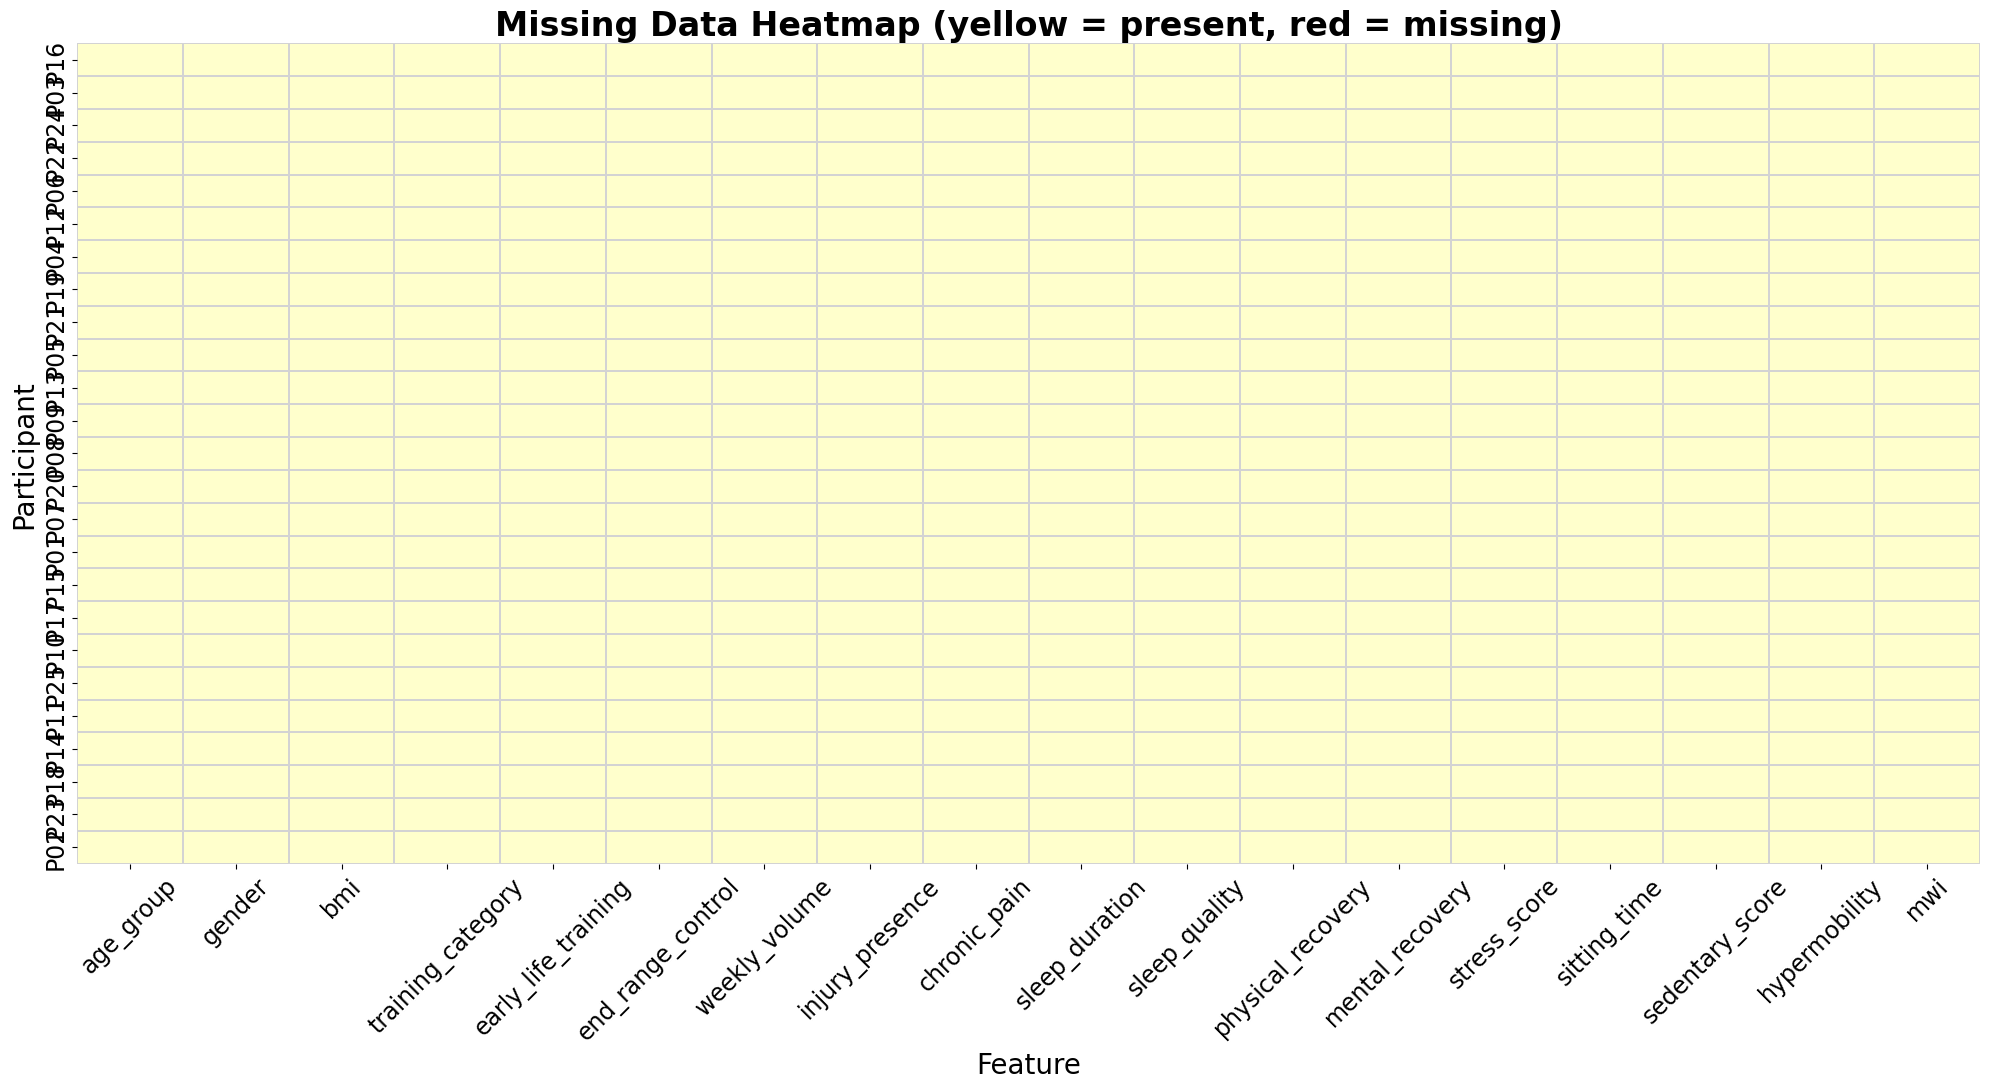

In [142]:
# Table: missing count and percentage per column
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(1)
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
})
missing_table = missing_table[missing_table['missing_count'] > 0].sort_values('missing_count', ascending=False)
print('=== Missing Data Summary ===')
print(missing_table.to_string())
print()

# Heatmap of missingness
fig, ax = plt.subplots(figsize=(20, 11))
sns.heatmap(
    df.set_index('name').isnull(),
    cbar=False,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    linecolor='lightgrey'
)
ax.set_title('Missing Data Heatmap (yellow = present, red = missing)', fontsize=24, fontweight='bold')
ax.set_xlabel('Feature', fontsize=20)
ax.set_ylabel('Participant', fontsize=20)
ax.tick_params(axis='x', rotation=45, labelsize=17)
ax.tick_params(axis='y', labelsize=17)
plt.tight_layout()
plt.show()


## 3. Data quality checks

In [143]:
EXPECTED_RANGES = {
    'bmi': (10, 60),
    'sleep_quality': (0, 10),
    'physical_recovery': (1, 6),
    'mental_recovery': (1, 6),
    'stress_score': (0, 4),
    'sitting_time': (4, 10),
    'sedentary_score': (-5, 11),
}

print('=== Out-of-Range Value Checks ===')
any_issues = False
for col, (lo, hi) in EXPECTED_RANGES.items():
    if col not in df.columns:
        print(f'  [{col}] NOT FOUND in dataframe')
        continue
    out = df[df[col].notna() & ((df[col] < lo) | (df[col] > hi))]
    if len(out) > 0:
        any_issues = True
        print(f'  [{col}] {len(out)} value(s) outside [{lo}, {hi}]:')
        print(out[['name', col]].to_string(index=False))
    else:
        print(f'  [{col}] OK — all values in [{lo}, {hi}]')

if not any_issues:
    print('No out-of-range issues found.')
print()

print('=== Duplicate Name Check ===')
dupes = df[df.duplicated(subset='name', keep=False)]
if len(dupes) > 0:
    print(f'Found {len(dupes)} duplicate name entries:')
    print(dupes[['name']].to_string())
else:
    print('No duplicate names found.')

=== Out-of-Range Value Checks ===
  [bmi] OK — all values in [10, 60]
  [sleep_quality] OK — all values in [0, 10]
  [physical_recovery] OK — all values in [1, 6]
  [mental_recovery] OK — all values in [1, 6]
  [stress_score] OK — all values in [0, 4]
  [sitting_time] OK — all values in [4, 10]
  [sedentary_score] OK — all values in [-5, 11]
No out-of-range issues found.

=== Duplicate Name Check ===
No duplicate names found.


## 4. Categorical Variable Distributions

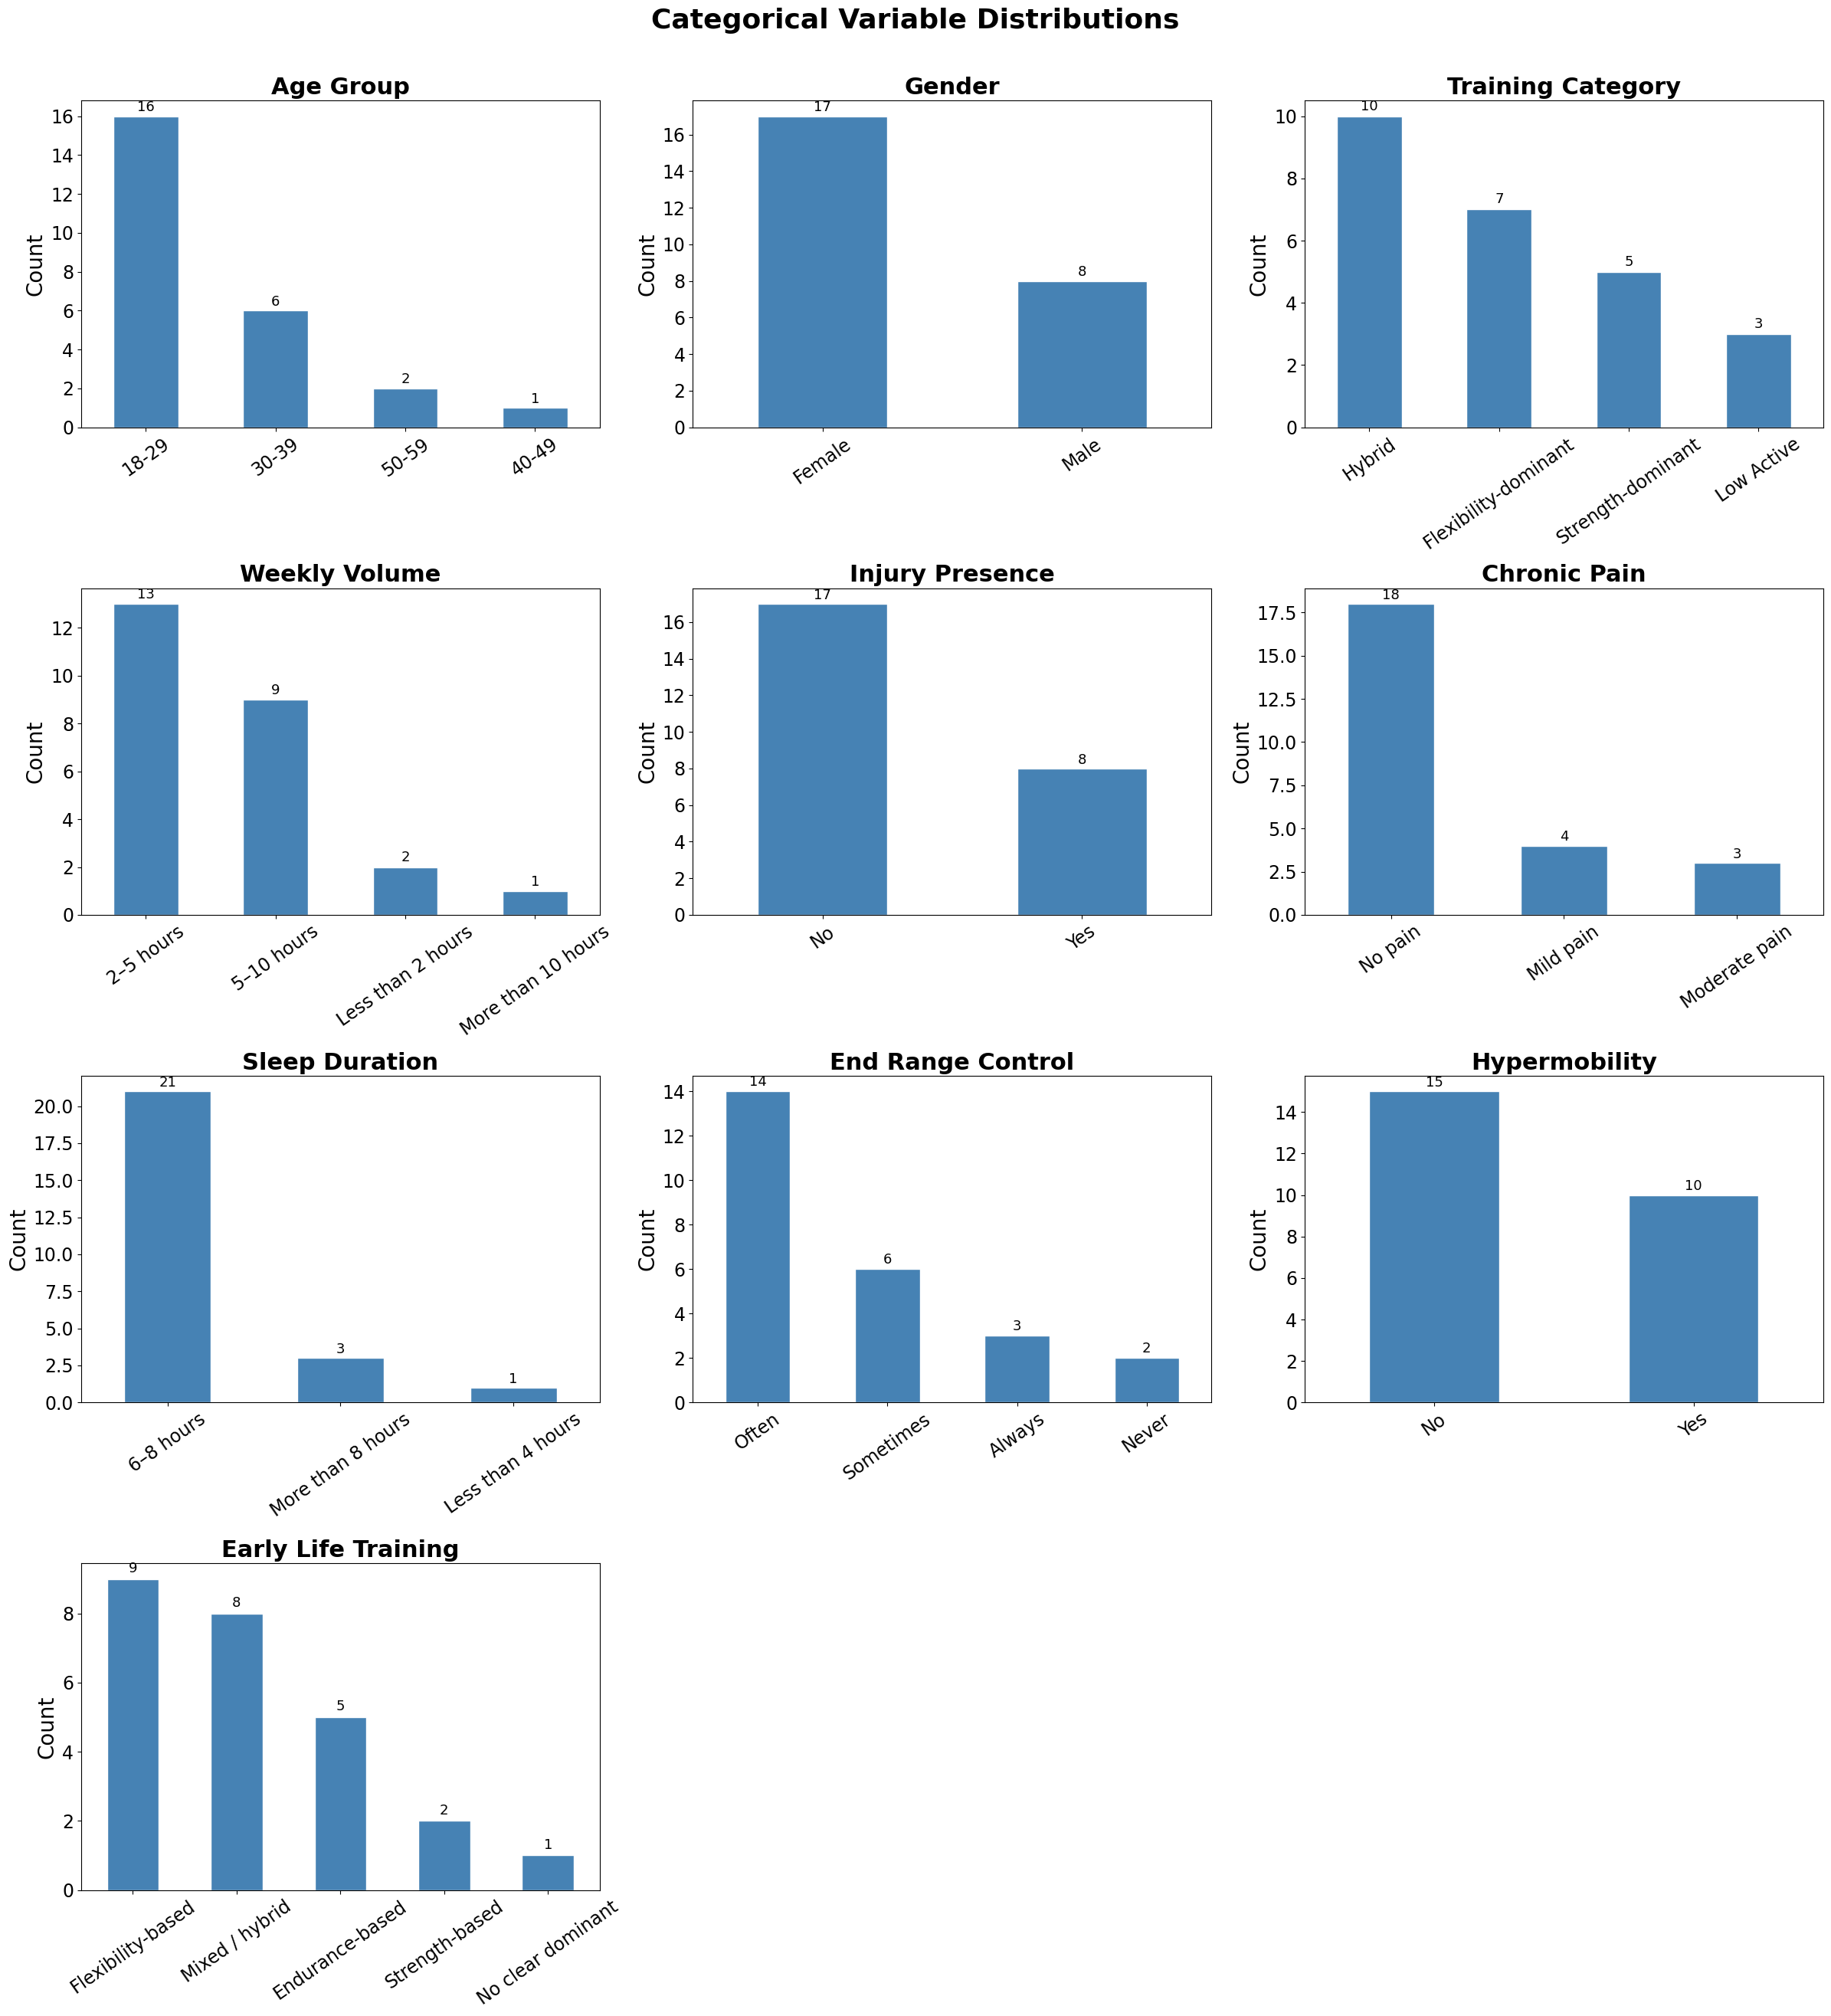

In [144]:
RAW_COLS = [
    'age_group', 'gender', 'training_category', 'weekly_volume', 'injury_presence',
    'chronic_pain', 'sleep_duration', 'end_range_control', 'hypermobility',
    'early_life_training',
]

fig, axes = plt.subplots(4, 3, figsize=(24, 26))
axes = axes.flatten()

for i, col in enumerate(RAW_COLS):
    ax = axes[i]
    if col not in df.columns:
        ax.set_visible(False)
        continue
    counts = df[col].value_counts(dropna=False)
    counts.index = counts.index.astype(str)
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_', ' ').title(), fontsize=22, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=20)
    ax.tick_params(axis='x', rotation=35, labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=13
        )

for j in range(len(RAW_COLS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Categorical Variable Distributions', fontsize=26, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [145]:

n = len(df)

RAW_COLS = [
    ('age_group',        'Age Group'),
    ('gender',           'Gender'),
    ('weekly_volume',    'Weekly Volume'),
    ('injury_presence',  'Injury Presence'),
    ('chronic_pain',     'Chronic Pain'),
    ('sleep_duration',   'Sleep Duration'),
    ('end_range_control','End-Range Control'),
    ('hypermobility',    'Hypermobility'),
]


for col, label in RAW_COLS:
    if col not in df.columns:
        continue
    counts = df[col].value_counts(dropna=True).sort_values(ascending=False)
    missing = df[col].isna().sum()
    valid_n = n - missing

    print(f'\n{label} (n={valid_n}{f", {missing} missing" if missing else ""})')
    print('-' * 45)

    dominant_cat   = counts.index[0]
    dominant_count = counts.iloc[0]
    dominant_pct   = 100 * dominant_count / valid_n

    for cat, cnt in counts.items():
        pct = 100 * cnt / valid_n
        bar = '█' * int(pct / 5)
        print(f'  {str(cat):35s} {cnt:3d} ({pct:5.1f}%)  {bar}')


print('\n' + '=' * 65)



Age Group (n=25)
---------------------------------------------
  18-29                                16 ( 64.0%)  ████████████
  30-39                                 6 ( 24.0%)  ████
  50-59                                 2 (  8.0%)  █
  40-49                                 1 (  4.0%)  

Gender (n=25)
---------------------------------------------
  Female                               17 ( 68.0%)  █████████████
  Male                                  8 ( 32.0%)  ██████

Weekly Volume (n=25)
---------------------------------------------
  2–5 hours                            13 ( 52.0%)  ██████████
  5–10 hours                            9 ( 36.0%)  ███████
  Less than 2 hours                     2 (  8.0%)  █
  More than 10 hours                    1 (  4.0%)  

Injury Presence (n=25)
---------------------------------------------
  No                                   17 ( 68.0%)  █████████████
  Yes                                   8 ( 32.0%)  ██████

Chronic Pain (n=25)
-------

## 5. Continuous Variable Distributions

Box plots with individual data points overlaid (preferred for small samples, n ≤ 25).

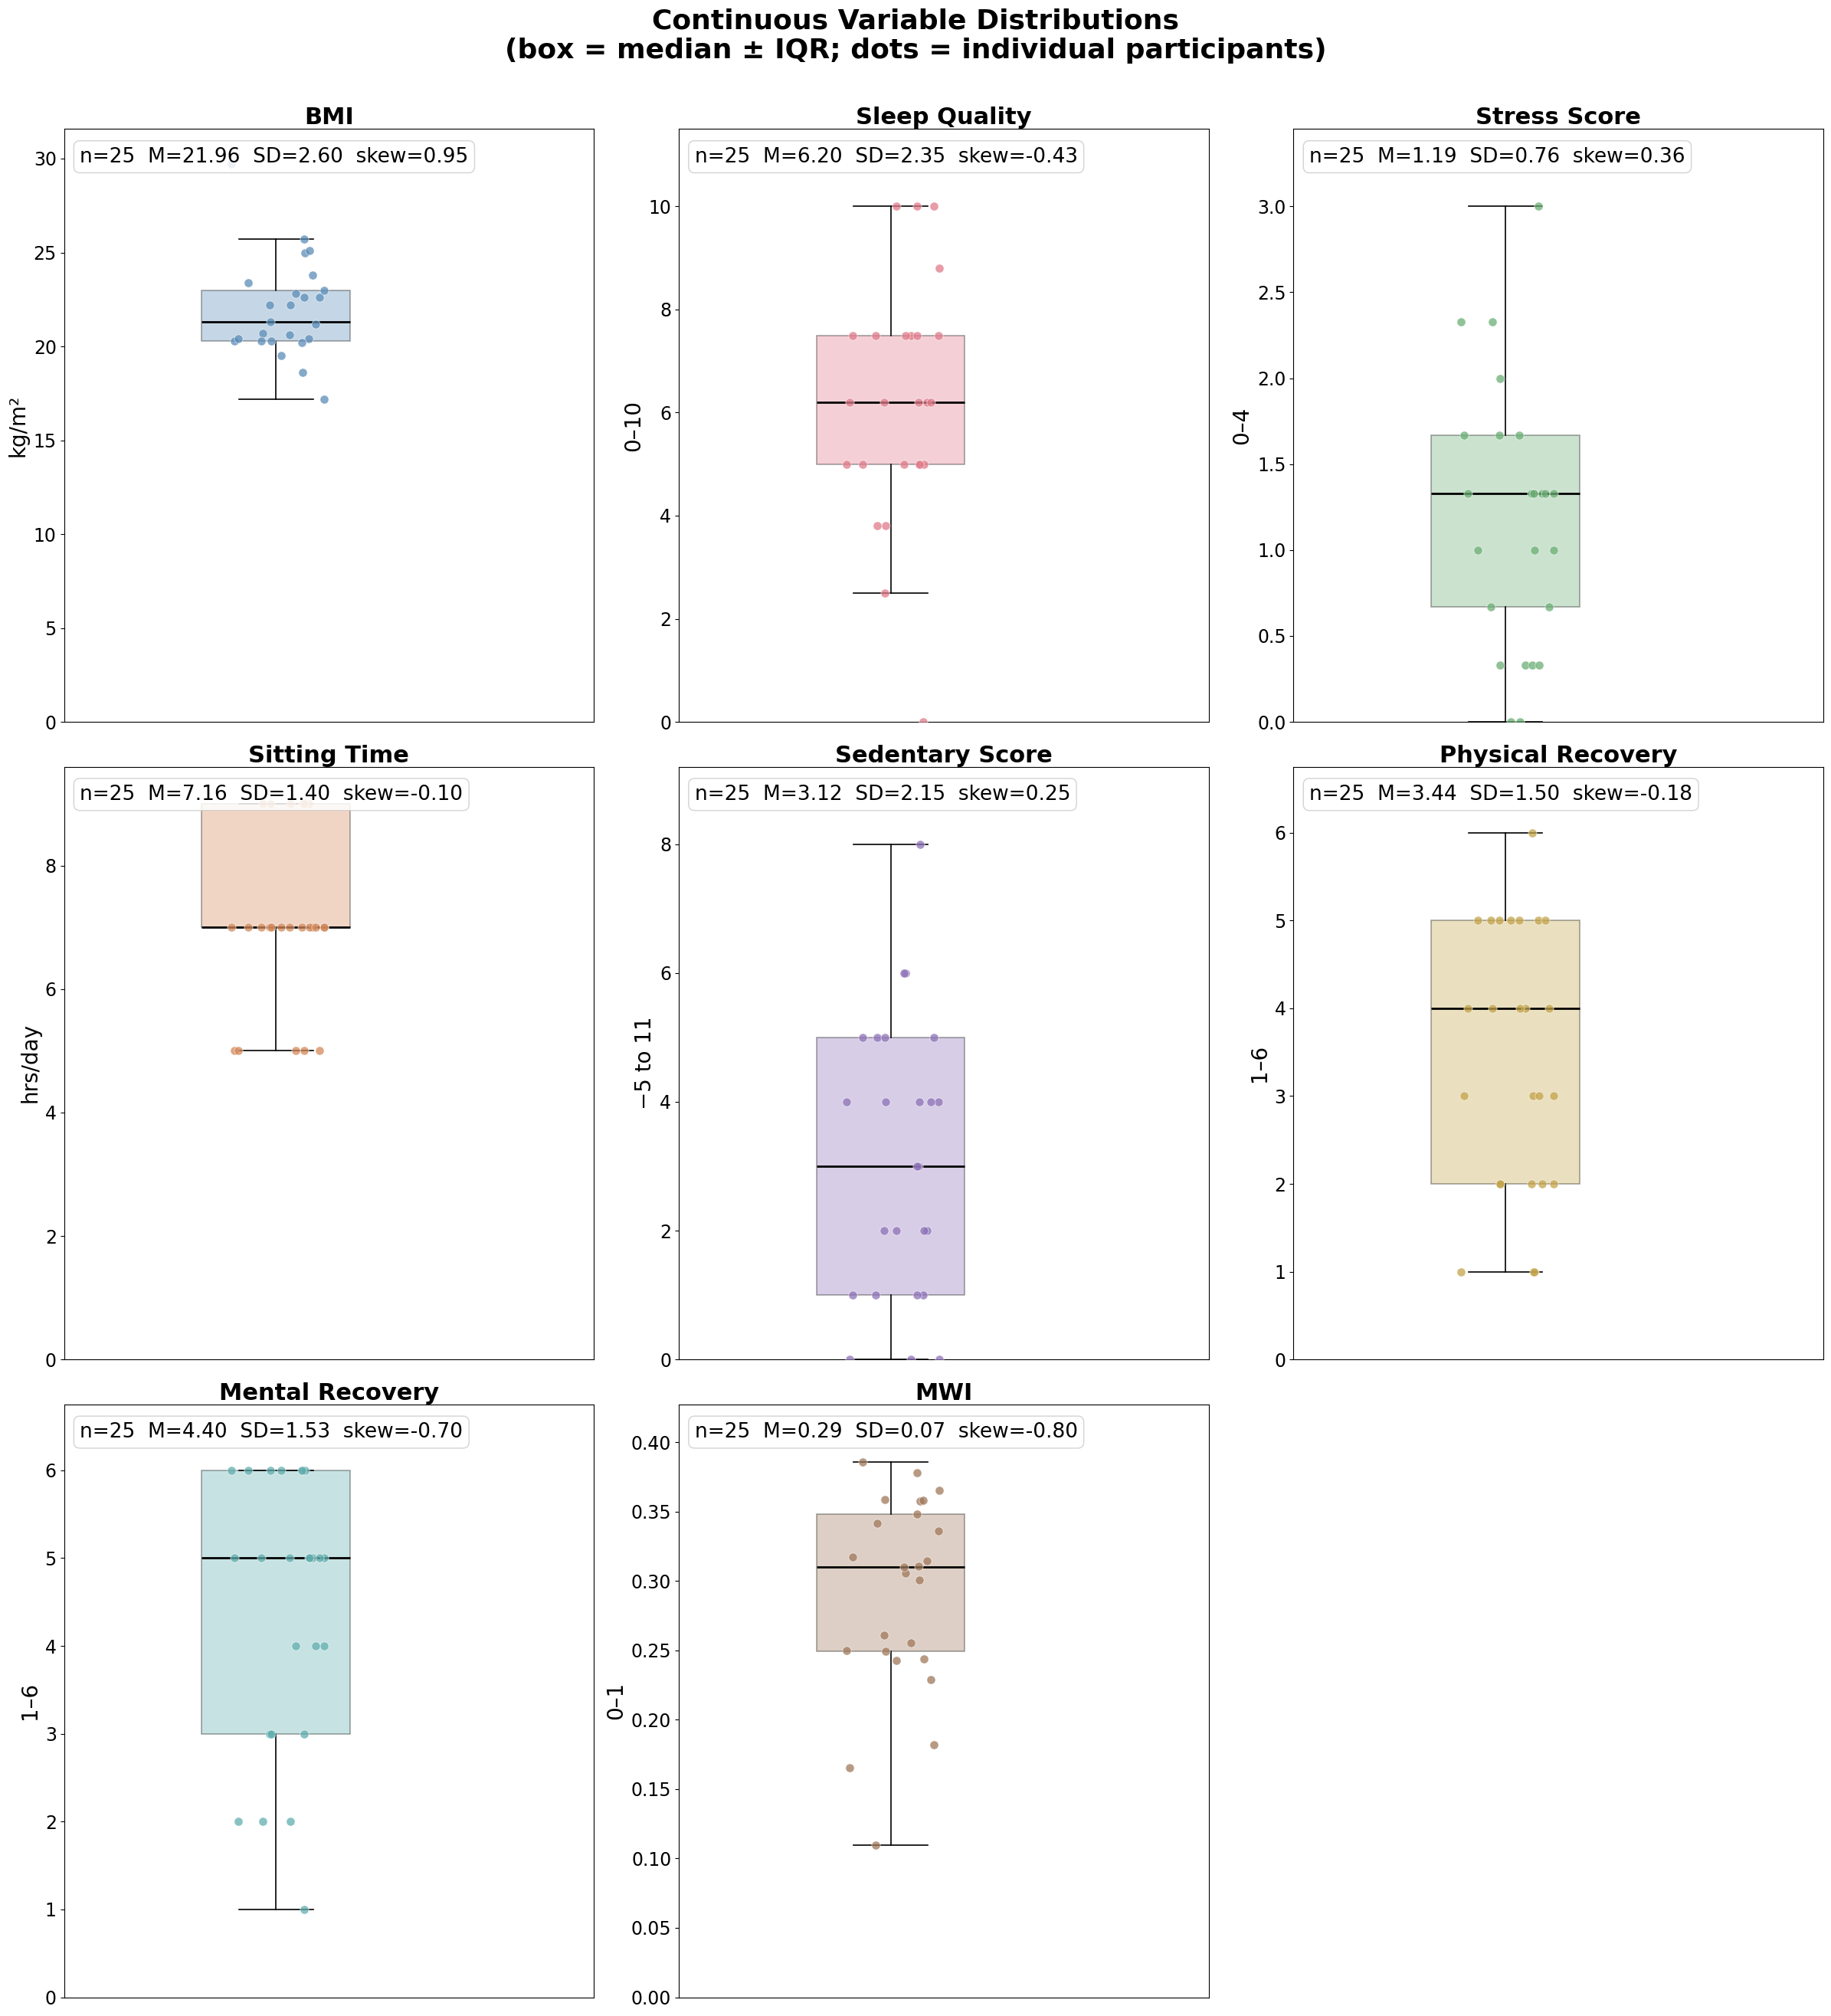

Variable                  n    Mean      SD     Mdn      Q1      Q3     Min     Max    Skew
----------------------------------------------------------------------------------------
BMI                      25   21.96    2.60   21.30   20.30   23.00   17.20   29.70    0.95
Sleep Quality            25    6.20    2.35    6.20    5.00    7.50    0.00   10.00   -0.43
Stress Score             25    1.19    0.76    1.33    0.67    1.67    0.00    3.00    0.36
Sitting Time             25    7.16    1.40    7.00    7.00    9.00    5.00    9.00   -0.10
Sedentary Score          25    3.12    2.15    3.00    1.00    5.00    0.00    8.00    0.25
Physical Recovery        25    3.44    1.50    4.00    2.00    5.00    1.00    6.00   -0.18
Mental Recovery          25    4.40    1.53    5.00    3.00    6.00    1.00    6.00   -0.70
MWI                      25    0.29    0.07    0.31    0.25    0.35    0.11    0.39   -0.80


In [146]:
from scipy import stats as _stats

CONT_VARS = [
    ('bmi',               'BMI',                   'kg/m²'),
    ('sleep_quality',     'Sleep Quality',          '0–10'),
    ('stress_score',      'Stress Score',           '0–4'),
    ('sitting_time',      'Sitting Time',           'hrs/day'),
    ('sedentary_score',   'Sedentary Score',        '−5 to 11'),
    ('physical_recovery', 'Physical Recovery',      '1–6'),
    ('mental_recovery',   'Mental Recovery',        '1–6'),
    ('mwi',               'MWI',                   '0–1'),
]

PALETTE = ['#5B8DB8', '#E07B8A', '#6BAE75', '#D4895A',
           '#8E72B8', '#C4A44A', '#60AEAE', '#A0785A']

ncols = 3
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(24, 26))
axes = axes.flatten()

for i, (col, label, unit) in enumerate(CONT_VARS):
    ax = axes[i]
    data  = df[col].dropna().values
    n     = len(data)
    color = PALETTE[i]

    pad   = (data.max() - data.min()) * 0.15
    y_top = data.max() + pad
    ax.set_ylim(0, y_top)

    ax.boxplot(data, positions=[0], widths=0.35,
               patch_artist=True, notch=False,
               boxprops=dict(facecolor=color, alpha=0.35, linewidth=1.2),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(linewidth=1.2),
               capprops=dict(linewidth=1.2),
               flierprops=dict(marker='', linestyle='none'),
               zorder=4)

    rng    = np.random.default_rng(42)
    jitter = rng.uniform(-0.12, 0.12, size=n)
    ax.scatter(jitter, data, color=color, alpha=0.75,
               edgecolors='white', linewidths=0.5, s=65, zorder=5)

    mean = np.mean(data)
    sd   = np.std(data, ddof=1)
    sk   = _stats.skew(data)
    ax.text(0.03, 0.97,
            f'n={n}  M={mean:.2f}  SD={sd:.2f}  skew={sk:.2f}',
            transform=ax.transAxes, fontsize=19, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#cccccc', alpha=0.85), zorder=6)

    ax.set_xlim(-0.5, 0.75)
    ax.set_xticks([])
    ax.set_title(label, fontsize=22, fontweight='bold', pad=4)
    ax.set_ylabel(unit, fontsize=20)
    ax.tick_params(axis='y', labelsize=17)

for j in range(len(CONT_VARS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Continuous Variable Distributions\n(box = median ± IQR; dots = individual participants)',
             fontsize=26, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary table 
print(f"{'Variable':<22} {'n':>4} {'Mean':>7} {'SD':>7} {'Mdn':>7} {'Q1':>7} {'Q3':>7} {'Min':>7} {'Max':>7} {'Skew':>7}")
print('-' * 88)
for col, label, _ in CONT_VARS:
    d = df[col].dropna()
    q1, q3 = np.percentile(d, [25, 75])
    print(f"{label:<22} {len(d):>4} {d.mean():>7.2f} {d.std(ddof=1):>7.2f} "
          f"{d.median():>7.2f} {q1:>7.2f} {q3:>7.2f} {d.min():>7.2f} {d.max():>7.2f} "
          f"{_stats.skew(d):>7.2f}")


In [147]:
# stats for continuous variables 
import numpy as np

CONT_COLS = [
    ('bmi',               'BMI',                 'kg/m²'),
    ('sleep_quality',     'Sleep Quality',       '0–10'),
    ('stress_score',      'Stress Score',        '0–4'),
    ('sitting_time',      'Sitting Time',        'hrs/day'),
    ('sedentary_score',   'Sedentary Score',     '−5 to 11'),
    ('physical_recovery', 'Physical Recovery',   '1–6'),
    ('mental_recovery',   'Mental Recovery',     '1–6'),
    ('mwi',               'MWI',                 '0–1'),
]

N_BINS = 5
BAR_SCALE = 5   # 1 block per 5%

for col, label, unit in CONT_COLS:
    if col not in df.columns:
        continue
    s = df[col].dropna()
    n = len(s)
    missing = df[col].isna().sum()
    mean, sd = s.mean(), s.std()
    median = s.median()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    vmin, vmax = s.min(), s.max()

    miss_str = f', {missing} missing' if missing else ''
    print(f'\n{label} ({unit})  (n={n}{miss_str})')
    print('-' * 55)
    print(f'  Mean ± SD   :  {mean:6.2f} ± {sd:.2f}')
    print(f'  Median [IQR]:  {median:.2f}  [{q1:.2f} – {q3:.2f}]')
    print(f'  Range        :  {vmin:.2f} – {vmax:.2f}')

    # Text histogram
    counts, edges = np.histogram(s, bins=N_BINS)
    print()
    for cnt, lo, hi in zip(counts, edges[:-1], edges[1:]):
        pct = 100 * cnt / n
        bar = '█' * max(int(pct / BAR_SCALE), (1 if cnt > 0 else 0))
        print(f'  {lo:6.2f} – {hi:6.2f}   {cnt:3d} ({pct:5.1f}%)  {bar}')

print('\n' + '=' * 65)



BMI (kg/m²)  (n=25)
-------------------------------------------------------
  Mean ± SD   :   21.96 ± 2.60
  Median [IQR]:  21.30  [20.30 – 23.00]
  Range        :  17.20 – 29.70

   17.20 –  19.70     3 ( 12.0%)  ██
   19.70 –  22.20    10 ( 40.0%)  ████████
   22.20 –  24.70     8 ( 32.0%)  ██████
   24.70 –  27.20     3 ( 12.0%)  ██
   27.20 –  29.70     1 (  4.0%)  █

Sleep Quality (0–10)  (n=25)
-------------------------------------------------------
  Mean ± SD   :    6.20 ± 2.35
  Median [IQR]:  6.20  [5.00 – 7.50]
  Range        :  0.00 – 10.00

    0.00 –   2.00     1 (  4.0%)  █
    2.00 –   4.00     3 ( 12.0%)  ██
    4.00 –   6.00     6 ( 24.0%)  ████
    6.00 –   8.00    11 ( 44.0%)  ████████
    8.00 –  10.00     4 ( 16.0%)  ███

Stress Score (0–4)  (n=25)
-------------------------------------------------------
  Mean ± SD   :    1.19 ± 0.76
  Median [IQR]:  1.33  [0.67 – 1.67]
  Range        :  0.00 – 3.00

    0.00 –   0.60     6 ( 24.0%)  ████
    0.60 –   1.20     5 

## 6. Outlier Detection

In [148]:
NUMERIC_COLS = [
    'bmi',
    'sleep_quality', 'physical_recovery', 'mental_recovery',
    'stress_score', 'sitting_time', 'sedentary_score',
    'mwi',
]

print('=== IQR-based Outlier Detection ===')
print(f"{'Variable':<22} {'Q1':>6} {'Q3':>6} {'IQR':>6} {'Fence low':>10} {'Fence high':>11} {'Outliers':<30}")
print('-' * 90)
any_found = False
for col in NUMERIC_COLS:
    if col not in df.columns:
        continue
    series = df[col].dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[df[col].notna() & ((df[col] < lower) | (df[col] > upper))]
    if len(outliers):
        out_str = ', '.join(f"{r['name'].split()[-1]} ({r[col]:.2f})" for _, r in outliers.iterrows())
        any_found = True
    else:
        out_str = 'none'
    print(f"{col:<22} {Q1:>6.2f} {Q3:>6.2f} {IQR:>6.2f} {lower:>10.2f} {upper:>11.2f}  {out_str}")

print()
if not any_found:
    print('No IQR outliers detected in any variable.')
else:
    print('Outliers listed as: Pnum.')

# Categorical: rare category check (n = 1)
CAT_COLS = [
    'age_group', 'training_category',
    'chronic_pain', 'sleep_duration', 'early_life_training',
]

print()
print('=== Rare Category Check (categorical variables) ===')
print(f"{'Variable':<25} {'Category':<35} {'n':>4} {'%':>6}  Flag")
print('-' * 80)
n_total = len(df)
for col in CAT_COLS:
    if col not in df.columns:
        continue
    counts = df[col].value_counts(dropna=True)
    valid_n = counts.sum()
    for cat, cnt in counts.items():
        pct = 100 * cnt / valid_n
        flag = '<-- singleton' if cnt == 1 else ('<-- rare (<5%)' if pct < 5 else '')
        if flag:
            print(f"{col:<25} {str(cat):<35} {cnt:>4} {pct:>5.1f}%  {flag}")
    if not any(100 * v / valid_n < 5 for v in counts.values):
        print(f"{col:<25} {'(all categories ≥ 5%)':<35}")

=== IQR-based Outlier Detection ===
Variable                   Q1     Q3    IQR  Fence low  Fence high Outliers                      
------------------------------------------------------------------------------------------
bmi                     20.30  23.00   2.70      16.25       27.05  P17 (29.70)
sleep_quality            5.00   7.50   2.50       1.25       11.25  P20 (0.00)
physical_recovery        2.00   5.00   3.00      -2.50        9.50  none
mental_recovery          3.00   6.00   3.00      -1.50       10.50  none
stress_score             0.67   1.67   1.00      -0.83        3.17  none
sitting_time             7.00   9.00   2.00       4.00       12.00  none
sedentary_score          1.00   5.00   4.00      -5.00       11.00  none
mwi                      0.25   0.35   0.10       0.10        0.50  none

Outliers listed as: Pnum.

=== Rare Category Check (categorical variables) ===
Variable                  Category                               n      %  Flag
------------------

## 7. Normality Tests (Shapiro-Wilk)

Shapiro-Wilk test applied to all continuous variables (n = 25). Results justify the use of non-parametric methods (Spearman correlation, Mann-Whitney U, Kruskal-Wallis) throughout the analysis.

In [149]:
from scipy.stats import shapiro

NORM_COLS = [
    ('bmi',               'BMI'),
    ('sleep_quality',     'Sleep Quality'),
    ('physical_recovery', 'Physical Recovery'),
    ('mental_recovery',   'Mental Recovery'),
    ('stress_score',      'Stress Score'),
    ('sitting_time',      'Sitting Time'),
    ('sedentary_score',   'Sedentary Score'),
    ('mwi',               'MWI'),
]

print('=== Shapiro-Wilk Normality Tests (n = 25) ===\n')
print(f'{"Variable":<22}  {"W":>7}  {"p":>7}  {"Normal (α=0.05)":>16}')
print('─' * 58)

for col, label in NORM_COLS:
    vals = df[col].dropna()
    stat, p = shapiro(vals)
    result = 'Yes' if p >= 0.05 else 'No  *'
    print(f'{label:<22}  {stat:>7.4f}  {p:>7.4f}  {result:>16}')

print('\n* p < 0.05 — normality rejected')

=== Shapiro-Wilk Normality Tests (n = 25) ===

Variable                      W        p   Normal (α=0.05)
──────────────────────────────────────────────────────────
BMI                      0.9327   0.1003               Yes
Sleep Quality            0.9444   0.1868               Yes
Physical Recovery        0.9124   0.0346             No  *
Mental Recovery          0.8687   0.0041             No  *
Stress Score             0.9536   0.3012               Yes
Sitting Time             0.8076   0.0003             No  *
Sedentary Score          0.9487   0.2345               Yes
MWI                      0.9292   0.0835               Yes

* p < 0.05 — normality rejected


## 7. Correlation Network

Full Spearman correlation matrix across all variables. Identifies confounded predictors (|ρ| > 0.50).

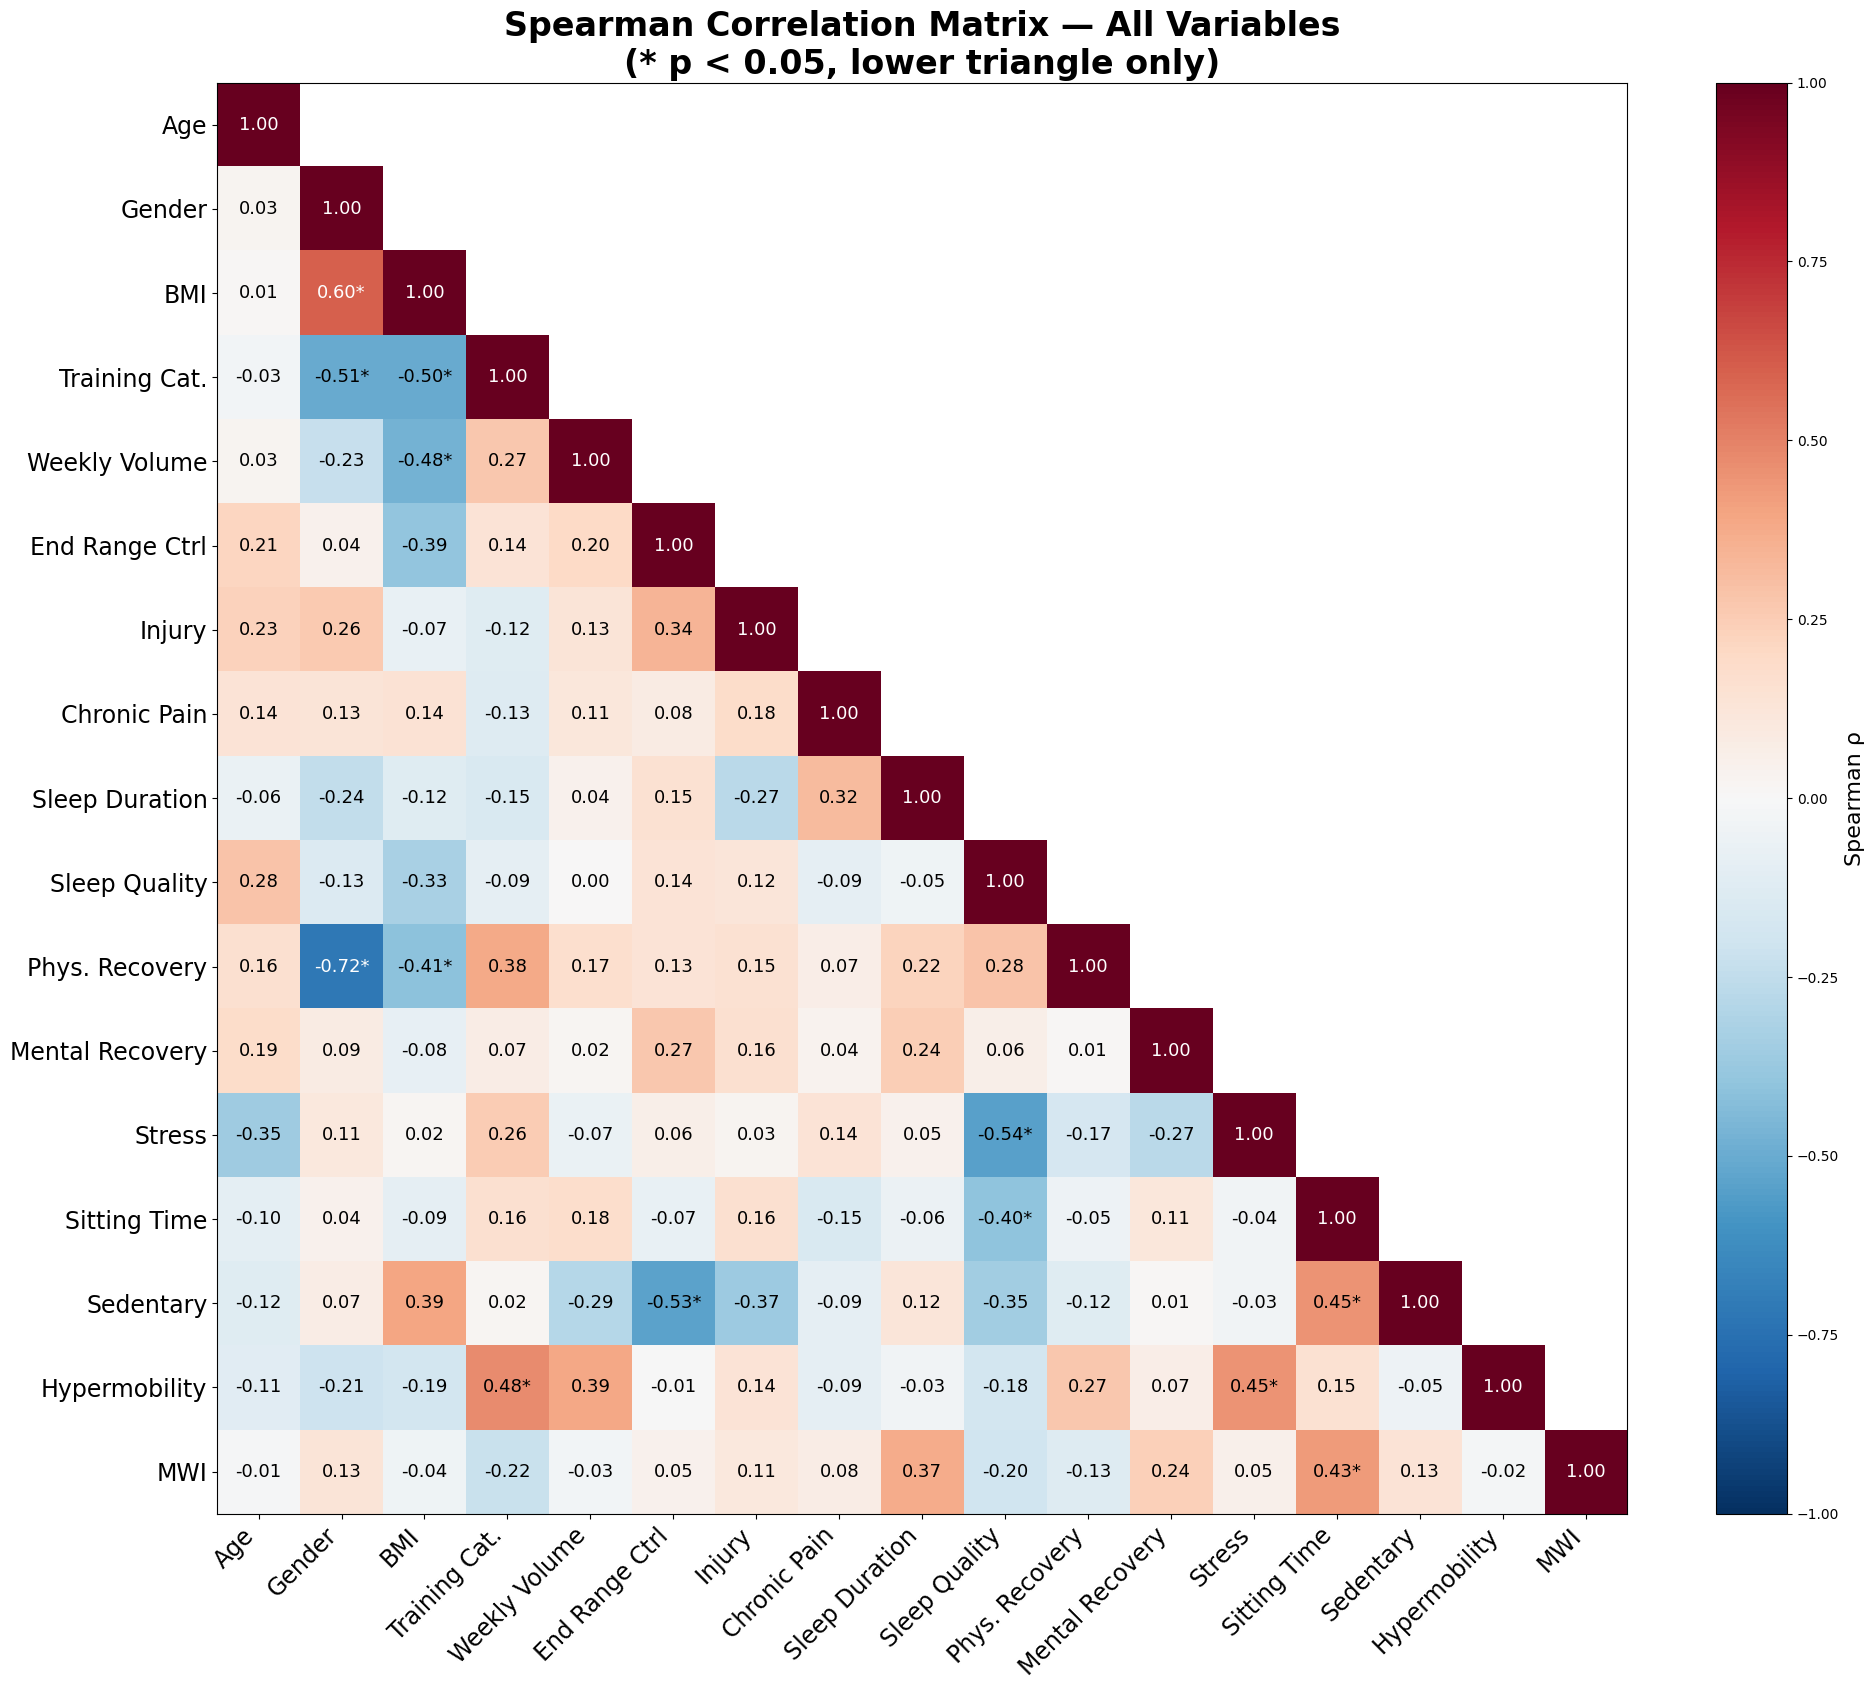

High correlations |ρ| > 0.50:
Variable 1            Variable 2                 ρ        p
------------------------------------------------------------
Gender                BMI                   +0.601  p=0.001 **
Gender                Training Cat.         -0.506  p=0.010 **
Gender                Phys. Recovery        -0.717  p=0.000 **
BMI                   Training Cat.         -0.501  p=0.011 *
End Range Ctrl        Sedentary             -0.532  p=0.006 **
Sleep Quality         Stress                -0.539  p=0.005 **


In [150]:
from scipy import stats as _stats

# Encode  variables numerically 
enc = df.copy()
enc['age_enc']        = enc['age_group'].map({'18-29':1,'30-39':2,'40-49':3,'50-59':4,'60+':5})
enc['gender_enc']     = enc['gender'].map({'Female':0,'Male':1})
enc['volume_enc']     = enc['weekly_volume'].map({'Less than 2 hours':1,'2–5 hours':2,'5–10 hours':3,'More than 10 hours':4})
enc['injury_enc']     = enc['injury_presence'].map({'No':0,'Yes':1})
enc['pain_enc']       = enc['chronic_pain'].map({'No pain':0,'Mild pain':1,'Moderate pain':2,'Severe pain':3})
enc['sleep_dur_enc']  = enc['sleep_duration'].map({'Less than 6 hours':1,'6–8 hours':2,'More than 8 hours':3})
enc['end_range_enc']  = enc['end_range_control'].map({'Never':0,'Sometimes':1,'Often':2,'Always':3})
enc['hyper_enc']      = enc['hypermobility'].map({'No':0,'Yes':1})
enc['training_enc']   = enc['training_category'].map({'Low Active':1,'Unclassified':2,'Strength-dominant':3,'Hybrid':4,'Flexibility-dominant':5})

CORR_COLS = {
    'age_enc':          'Age',
    'gender_enc':       'Gender',
    'bmi':              'BMI',
    'training_enc':     'Training Cat.',
    'volume_enc':       'Weekly Volume',
    'end_range_enc':    'End Range Ctrl',
    'injury_enc':       'Injury',
    'pain_enc':         'Chronic Pain',
    'sleep_dur_enc':    'Sleep Duration',
    'sleep_quality':    'Sleep Quality',
    'physical_recovery':'Phys. Recovery',
    'mental_recovery':  'Mental Recovery',
    'stress_score':     'Stress',
    'sitting_time':     'Sitting Time',
    'sedentary_score':  'Sedentary',
    'hyper_enc':        'Hypermobility',
    'mwi':              'MWI',
}

corr_df = enc[[c for c in CORR_COLS]].rename(columns=CORR_COLS).dropna(how='all')
n = len(corr_df.columns)
rho_mat = np.full((n, n), np.nan)
p_mat   = np.full((n, n), np.nan)

cols = list(corr_df.columns)
for i in range(n):
    for j in range(n):
        if i == j:
            rho_mat[i, j] = 1.0
            p_mat[i, j]   = 0.0
        else:
            sub = corr_df[[cols[i], cols[j]]].dropna()
            if len(sub) >= 4:
                r, p = _stats.spearmanr(sub.iloc[:, 0], sub.iloc[:, 1])
                rho_mat[i, j] = float(r)
                p_mat[i, j]   = float(p)

rho_df = pd.DataFrame(rho_mat, index=cols, columns=cols)

# Heatmap 
fig, ax = plt.subplots(figsize=(20, 17))
mask = np.triu(np.ones_like(rho_mat, dtype=bool), k=1)
im = ax.imshow(np.where(mask, np.nan, rho_mat), cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Spearman ρ', fontsize=16)

ax.set_xticks(range(n)); ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=17)
ax.set_yticks(range(n)); ax.set_yticklabels(cols, fontsize=17)

for i in range(n):
    for j in range(n):
        if not mask[i, j] and pd.notna(rho_mat[i, j]):
            val = rho_mat[i, j]
            sig = '*' if (pd.notna(p_mat[i,j]) and p_mat[i,j] < 0.05 and i != j) else ''
            ax.text(j, i, f'{val:.2f}{sig}', ha='center', va='center',
                    fontsize=13, color='white' if abs(val) > 0.6 else 'black')

ax.set_title('Spearman Correlation Matrix — All Variables\n(* p < 0.05, lower triangle only)',
             fontweight='bold', fontsize=24)
plt.tight_layout()
plt.show()

# High correlations |ρ| > 0.5
print('High correlations |ρ| > 0.50:')
print(f'{"Variable 1":20s}  {"Variable 2":20s}  {"ρ":>6}  {"p":>7}')
print('-' * 60)
found = False
for i in range(n):
    for j in range(i+1, n):
        if pd.notna(rho_mat[i,j]) and abs(rho_mat[i,j]) > 0.50:
            found = True
            sig = '**' if p_mat[i,j] < 0.01 else ('*' if p_mat[i,j] < 0.05 else '')
            print(f'{cols[i]:20s}  {cols[j]:20s}  {rho_mat[i,j]:+.3f}  p={p_mat[i,j]:.3f} {sig}')
if not found:
    print('  None found.')
